## 1. Importar librerías

In [33]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Cargar y Visualizar Imágenes sin Fondo

In [34]:
# Buscar carpetas con imágenes sin fondo
data_path = "data_sin_fondo"
fruit_folders = ['banana_sin_fondo', 'manzana_sin_fondo', 'naranja_sin_fondo', 'zapallo_sin_fondo']

# Verificar que existen
available_folders = []
for fruit in fruit_folders:
    folder_path = os.path.join(data_path, fruit)
    if os.path.exists(folder_path):
        images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        available_folders.append((fruit, len(images)))
        print(f"✓ {fruit}: {len(images)} imágenes")
    else:
        print(f"⚠ {fruit}: NO ENCONTRADA")

print(f"\nTotal de carpetas disponibles: {len(available_folders)}")

✓ banana_sin_fondo: 4 imágenes
✓ manzana_sin_fondo: 4 imágenes
✓ naranja_sin_fondo: 4 imágenes
✓ zapallo_sin_fondo: 4 imágenes

Total de carpetas disponibles: 4


## 3. Visualizar Ejemplo Antes y Después de Suavizado

In [35]:
# Cargar una imagen de ejemplo
example_path = os.path.join(data_path, 'banana_sin_fondo')
example_images = [f for f in os.listdir(example_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

if example_images:
    img_file = os.path.join(example_path, example_images[0])
    original = cv2.imread(img_file, cv2.IMREAD_UNCHANGED)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGRA2RGB)
    
    print(f"Imagen: {example_images[0]}")
    print(f"Dimensiones: {original.shape}")
    print(f"Canales: {original.shape[2] if len(original.shape) > 2 else 1} (con RGBA/transparencia)")
else:
    print("No hay imágenes en banana_sin_fondo")

Imagen: banana2.png
Dimensiones: (2304, 4096, 4)
Canales: 4 (con RGBA/transparencia)


## 4. Técnicas de Suavizado

Vamos a probar 3 técnicas de suavizado para limpiar la imagen:

In [36]:
def apply_smoothing_techniques(image_bgra):
    """Aplica diferentes técnicas de suavizado a una imagen RGBA"""
    
    # Separar canal alpha (transparencia)
    bgr = image_bgra[:,:,:3]
    alpha = image_bgra[:,:,3] if image_bgra.shape[2] == 4 else None
    
    results = {}
    
    # 1. Filtro Bilateral (preserva bordes, suaviza interior)
    bilateral = cv2.bilateralFilter(bgr, d=9, sigmaColor=75, sigmaSpace=75)
    if alpha is not None:
        bilateral = cv2.merge([bilateral[:,:,0], bilateral[:,:,1], bilateral[:,:,2], alpha])
    results['Bilateral'] = bilateral
    
    # 2. Filtro Gaussiano (suavizado general)
    gaussian = cv2.GaussianBlur(bgr, (5, 5), 0)
    if alpha is not None:
        gaussian = cv2.merge([gaussian[:,:,0], gaussian[:,:,1], gaussian[:,:,2], alpha])
    results['Gaussiano'] = gaussian
    
    # 3. Filtro Mediana (elimina ruido, preserva bordes)
    median = cv2.medianBlur(bgr, 5)
    if alpha is not None:
        median = cv2.merge([median[:,:,0], median[:,:,1], median[:,:,2], alpha])
    results['Mediana'] = median
    
    # 4. Morfología: apertura (elimina ruido pequeño)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    morph = cv2.morphologyEx(bgr, cv2.MORPH_OPEN, kernel, iterations=2)
    if alpha is not None:
        morph = cv2.merge([morph[:,:,0], morph[:,:,1], morph[:,:,2], alpha])
    results['Morfología'] = morph
    
    # 5. Combinado: Bilateral + Mediana (mejor resultado)
    combined = cv2.bilateralFilter(bgr, d=7, sigmaColor=50, sigmaSpace=50)
    combined = cv2.medianBlur(combined, 3)
    if alpha is not None:
        combined = cv2.merge([combined[:,:,0], combined[:,:,1], combined[:,:,2], alpha])
    results['Bilateral+Mediana'] = combined
    
    return results

# Aplicar técnicas
smoothed_images = apply_smoothing_techniques(original)
print(f"✓ Se aplicaron {len(smoothed_images)} técnicas de suavizado")

✓ Se aplicaron 5 técnicas de suavizado


## 5. Visualizar Comparación de Suavizado

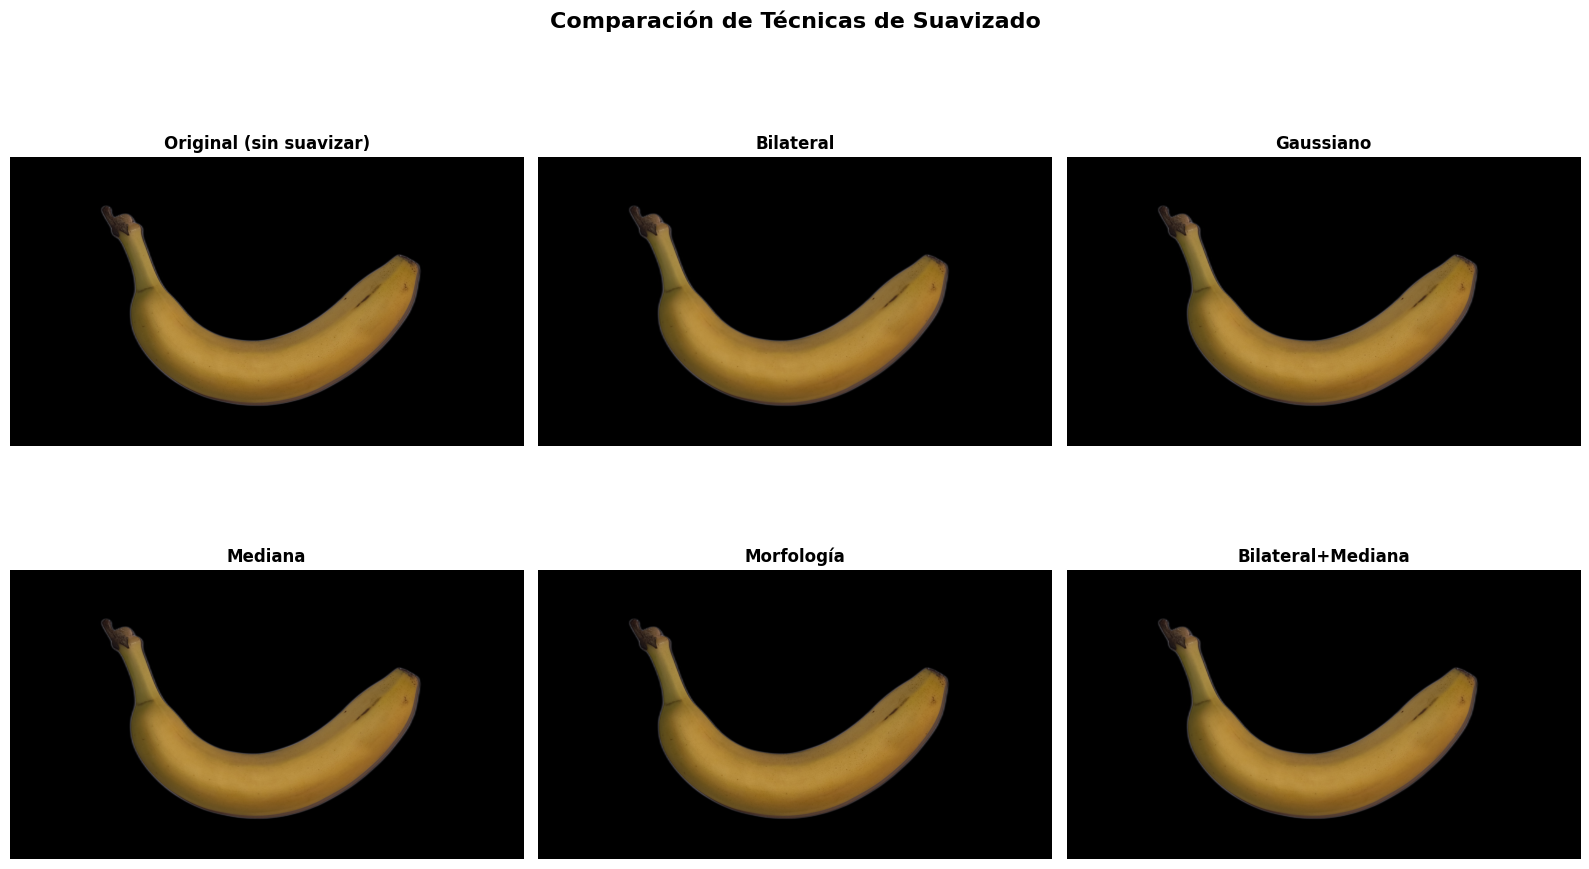

✓ Visualización completada


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparación de Técnicas de Suavizado', fontsize=16, fontweight='bold')

# Original
axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGRA2RGB))
axes[0, 0].set_title('Original (sin suavizar)', fontweight='bold')
axes[0, 0].axis('off')

# Técnicas suavizadas
techniques = list(smoothed_images.keys())
positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for (row, col), technique in zip(positions, techniques):
    img = smoothed_images[technique]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    axes[row, col].imshow(img_rgb)
    axes[row, col].set_title(f'{technique}', fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualización completada")

## 6. Función para Extraer Features

In [38]:
def extract_features_from_fruit(image_bgra, apply_smoothing=True):
    """
    Extrae los 516 features de una imagen de fruta sin fondo.
    
    Retorna:
        - features: vector de 516 valores
        - debug_info: diccionario con información de debug
    """
    
    # Separar RGB del canal alpha
    bgr = image_bgra[:,:,:3]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    alpha = image_bgra[:,:,3] if image_bgra.shape[2] == 4 else None
    
    # 1. SUAVIZADO (usar Bilateral + Mediana como está demostrado que es mejor)
    if apply_smoothing:
        rgb_smooth = cv2.bilateralFilter(rgb, d=7, sigmaColor=50, sigmaSpace=50)
        rgb_smooth = cv2.medianBlur(rgb_smooth, 3)
    else:
        rgb_smooth = rgb.copy()
    
    # 2. Convertir a Escala de Grises para contorno
    gray = cv2.cvtColor(rgb_smooth, cv2.COLOR_RGB2GRAY)
    
    # 3. Crear máscara binaria del objeto (usando alpha channel o threshold)
    if alpha is not None:
        # Usar canal alpha directamente
        _, binary = cv2.threshold(alpha, 127, 255, cv2.THRESH_BINARY)
    else:
        # Si no hay alpha, usar threshold en escala de grises
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # 4. FEATURES DE FORMA: Hu Moments, Circularidad, Compacidad
    # Calcular momentos
    moments = cv2.moments(binary)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Seleccionar solo 2 Hu Moments (hu[0] y hu[3]) y normalizar
    hu_selected = np.array([hu_moments[0], hu_moments[3]])
    d0 = 1e-8  # Constante para evitar log(0)
    hu_normalized = np.log10(np.abs(hu_selected) + d0)
    
    # Encontrar contornos
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) > 0:
        # Usar el contorno más grande
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Suavizar contorno
        epsilon = 0.02 * cv2.arcLength(largest_contour, True)
        smooth_contour = cv2.approxPolyDP(largest_contour, epsilon, True)
        
        # Calcular área y perímetro
        area = cv2.contourArea(smooth_contour)
        perimeter = cv2.arcLength(smooth_contour, True)
        
        # Circularidad: (4π * área) / perímetro²
        if perimeter > 0:
            circularity = (4 * np.pi * area) / (perimeter ** 2)
        else:
            circularity = 0
        
        # Compacidad: perímetro² / área
        if area > 0:
            compactness = (perimeter ** 2) / area
        else:
            compactness = 0
        
        # Normalizar
        circ_normalized = np.log10(np.abs(circularity) + d0)
        compact_normalized = np.log10(np.abs(compactness) + d0)
    else:
        circ_normalized = 0
        compact_normalized = 0
        area = 0
        perimeter = 0
    
    # 5. FEATURES DE COLOR: Histogramas HSV
    hsv = cv2.cvtColor(rgb_smooth, cv2.COLOR_RGB2HSV)
    
    # Histograma Hue (256 bins)
    hist_hue = cv2.calcHist([hsv], [0], alpha if alpha is not None else None, [256], (0, 256))
    hist_hue = cv2.normalize(hist_hue, hist_hue).flatten()
    
    # Histograma Saturación (256 bins)
    hist_saturation = cv2.calcHist([hsv], [1], alpha if alpha is not None else None, [256], (0, 256))
    hist_saturation = cv2.normalize(hist_saturation, hist_saturation).flatten()
    
    # 6. CONCATENAR TODOS LOS FEATURES
    features = np.concatenate([
        hu_normalized,           # 2 valores
        hist_hue,               # 256 valores
        hist_saturation,        # 256 valores
        [circ_normalized],      # 1 valor
        [compact_normalized]    # 1 valor
    ])
    
    # Normalización final
    features = cv2.normalize(features, features).flatten()
    
    # Información de debug
    debug_info = {
        'hu_moments': hu_normalized,
        'circularity': circularity,
        'compactness': compactness,
        'area': area,
        'perimeter': perimeter,
        'num_features': len(features)
    }
    
    return features, debug_info

print("✓ Función de extracción de features definida")

✓ Función de extracción de features definida


## 7. Probar Extracción en Imagen de Ejemplo

In [39]:
# Extraer features del ejemplo
features_example, debug = extract_features_from_fruit(original, apply_smoothing=True)

print(f"✓ Features extraídos exitosamente")
print(f"\n📊 Información de Debug:")
print(f"  Hu Moments: {debug['hu_moments']}")
print(f"  Circularidad: {debug['circularity']:.4f}")
print(f"  Compacidad: {debug['compactness']:.4f}")
print(f"  Área: {debug['area']:.0f} píxeles")
print(f"  Perímetro: {debug['perimeter']:.0f} píxeles")
print(f"  Total de features: {debug['num_features']}")
print(f"\n✓ Vector de features tiene {len(features_example)} valores (esperado: 516)")
print(f"\nPrimeros 20 valores: {features_example[:20]}")

✓ Features extraídos exitosamente

📊 Información de Debug:
  Hu Moments: [-2.77963048 -7.98263463]
  Circularidad: 0.3276
  Compacidad: 38.3566
  Área: 1327492 píxeles
  Perímetro: 7136 píxeles
  Total de features: 516

✓ Vector de features tiene 516 valores (esperado: 516)

Primeros 20 valores: [-3.18443035e-01 -9.14515228e-01  1.21440502e-02  0.00000000e+00
  1.02048036e-04  2.75412787e-04  2.19461739e-04  4.39090483e-04
  4.30071512e-04  4.34581011e-04  9.17263198e-04  1.93089583e-03
  3.33401455e-03  2.94686680e-03  1.36821200e-03  1.14791514e-03
  1.16578605e-03  1.09229814e-03  1.28520400e-03  7.81794883e-03]


## 8. Procesar Todas las Frutas y Guardar Features

In [42]:
def process_all_fruits_and_extract_features(data_path="data_sin_fondo"):
    """
    Procesa todas las frutas sin fondo y extrae features.
    Guarda los features en archivos CSV.
    """
    
    fruit_folders = {
        'banana': 'banana_sin_fondo',
        'manzana': 'manzana_sin_fondo',
        'naranja': 'naranja_sin_fondo',
        'zapallo': 'zapallo_sin_fondo'
    }
    
    all_features = []
    all_labels = []
    
    for label, folder_name in fruit_folders.items():
        folder_path = os.path.join(data_path, folder_name)
        
        if not os.path.exists(folder_path):
            print(f"⚠ Carpeta {folder_name} no encontrada, saltando...")
            continue
        
        images = sorted([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
        print(f"\n{'='*60}")
        print(f"Procesando {label.upper()}: {len(images)} imágenes")
        print(f"{'='*60}")
        
        for idx, img_name in enumerate(images, 1):
            try:
                img_path = os.path.join(folder_path, img_name)
                img_bgra = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
                
                if img_bgra is None:
                    print(f"  ⚠ Error al leer {img_name}")
                    continue
                
                # Redimensionar a 200x200 (estándar)
                img_resized = cv2.resize(img_bgra, (200, 200))
                
                # Extraer features
                features, debug = extract_features_from_fruit(img_resized, apply_smoothing=True)
                
                all_features.append(features)
                all_labels.append(label)
                
                # Mostrar progreso
                if idx % max(1, len(images)//5) == 0 or idx == len(images):
                    print(f"  [{idx}/{len(images)}] {img_name} - Circularidad: {debug['circularity']:.3f}, Compacidad: {debug['compactness']:.3f}")
                
            except Exception as e:
                print(f"  ⚠ Error procesando {img_name}: {e}")
        
        print(f"✓ {label}: {sum(1 for l in all_labels if l == label)} imágenes procesadas")
    
    return np.array(all_features), np.array(all_labels)

# Ejecutar
print("\n" + "#"*60)
print("# EXTRAYENDO FEATURES DE TODAS LAS FRUTAS")
print("#"*60)

X_features, y_labels = process_all_fruits_and_extract_features()

print(f"\n\n{'='*60}")
print("RESUMEN FINAL")
print(f"{'='*60}")
print(f"✓ Total de imágenes procesadas: {len(X_features)}")
print(f"✓ Dimensiones del dataset: {X_features.shape}")
print(f"\nDistribución:")
unique, counts = np.unique(y_labels, return_counts=True)
for fruit, count in zip(unique, counts):
    print(f"  - {fruit}: {count} imágenes")


############################################################
# EXTRAYENDO FEATURES DE TODAS LAS FRUTAS
############################################################

Procesando BANANA: 4 imágenes
  [1/4] banana1.png - Circularidad: 0.313, Compacidad: 40.191
  [2/4] banana2.png - Circularidad: 0.321, Compacidad: 39.131
  [3/4] banana3.png - Circularidad: 0.349, Compacidad: 36.033
  [4/4] banana4.png - Circularidad: 0.329, Compacidad: 38.214
✓ banana: 4 imágenes procesadas

Procesando MANZANA: 4 imágenes
  [1/4] manzana1.png - Circularidad: 0.849, Compacidad: 14.793
  [2/4] manzana2.png - Circularidad: 0.812, Compacidad: 15.477
  [3/4] manzana3.png - Circularidad: 0.812, Compacidad: 15.471
  [4/4] manzana4.png - Circularidad: 0.815, Compacidad: 15.411
✓ manzana: 4 imágenes procesadas

Procesando NARANJA: 4 imágenes
  [1/4] naranja1.png - Circularidad: 0.833, Compacidad: 15.084
  [2/4] naranja2.png - Circularidad: 0.836, Compacidad: 15.031
  [3/4] naranja3.png - Circularidad: 0.838, Compa

## 9. Guardar Features en CSV

In [43]:
# Crear DataFrame con features
feature_names = ['HU_0', 'HU_1'] + [f'HIST_HUE_{i}' for i in range(256)] + [f'HIST_SAT_{i}' for i in range(256)] + ['CIRCULARITY', 'COMPACTNESS']

df_features = pd.DataFrame(X_features, columns=feature_names)
df_features['label'] = y_labels
df_features['fruit'] = y_labels

# Guardar en CSV
output_path = 'features_frutas.csv'
df_features.to_csv(output_path, index=False)
print(f"✓ Features guardados en: {output_path}")
print(f"✓ Dimensiones del CSV: {df_features.shape}")
print(f"\nPrimeras 3 filas del dataset:")
print(df_features.iloc[:3, :10])  # Mostrar primeras 10 columnas de las primeras 3 filas

✓ Features guardados en: features_frutas.csv
✓ Dimensiones del CSV: (16, 518)

Primeras 3 filas del dataset:
       HU_0      HU_1  HIST_HUE_0  HIST_HUE_1  HIST_HUE_2  HIST_HUE_3  \
0 -0.328706 -0.910489    0.015540         0.0    0.000000    0.000039   
1 -0.329127 -0.910729    0.016425         0.0    0.000000    0.000412   
2 -0.319492 -0.914628    0.014728         0.0    0.000079    0.000118   

   HIST_HUE_4  HIST_HUE_5  HIST_HUE_6  HIST_HUE_7  
0    0.000077    0.000232    0.000232    0.000077  
1    0.000150    0.000150    0.000412    0.000375  
2    0.000157    0.000157    0.000236    0.000275  


## 10. Análisis de Features Extraídos

In [44]:
# Estadísticas por fruta
print("\n" + "="*60)
print("ESTADÍSTICAS DE FEATURES POR FRUTA")
print("="*60)

for fruit in df_features['fruit'].unique():
    fruit_data = df_features[df_features['fruit'] == fruit]
    
    circ_values = fruit_data['CIRCULARITY'].values
    compact_values = fruit_data['COMPACTNESS'].values
    
    print(f"\n{fruit.upper()}:")
    print(f"  Circularidad: media={circ_values.mean():.3f}, std={circ_values.std():.3f}")
    print(f"  Compacidad: media={compact_values.mean():.3f}, std={compact_values.std():.3f}")


ESTADÍSTICAS DE FEATURES POR FRUTA

BANANA:
  Circularidad: media=-0.056, std=0.002
  Compacidad: media=0.182, std=0.002

MANZANA:
  Circularidad: media=-0.010, std=0.001
  Compacidad: media=0.135, std=0.001

NARANJA:
  Circularidad: media=-0.009, std=0.000
  Compacidad: media=0.134, std=0.000

ZAPALLO:
  Circularidad: media=-0.008, std=0.001
  Compacidad: media=0.133, std=0.001


## 11. Visualizar Histogramas de Features

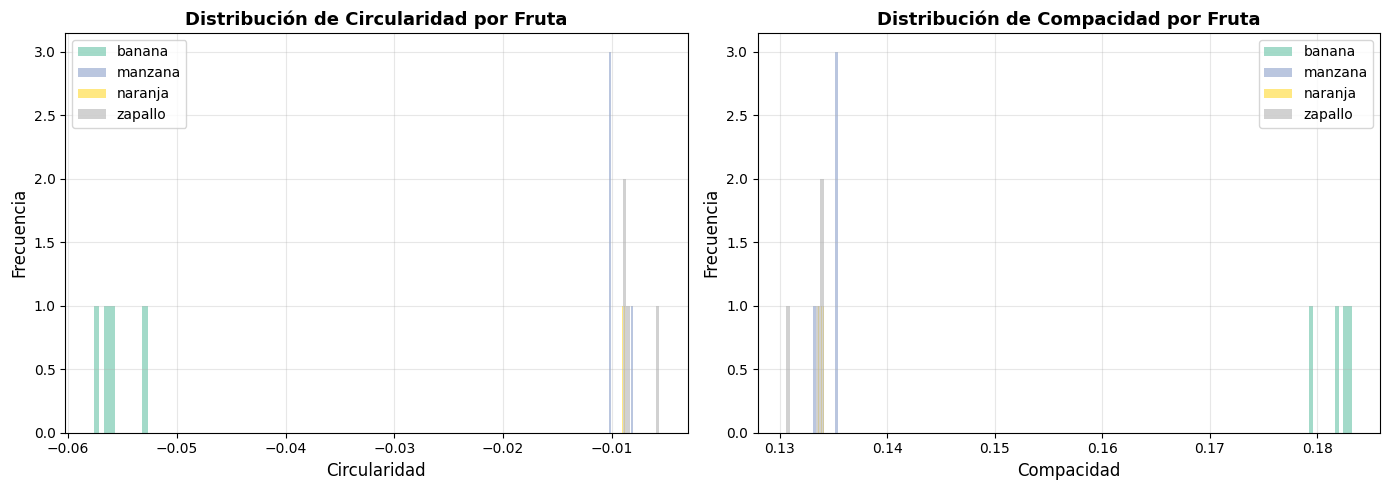

✓ Visualización completada


In [45]:
# Visualizar Circularidad y Compacidad por fruta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fruits = df_features['fruit'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(fruits)))

# Circularidad
for fruit, color in zip(fruits, colors):
    data = df_features[df_features['fruit'] == fruit]['CIRCULARITY']
    axes[0].hist(data, alpha=0.6, label=fruit, color=color, bins=10)
axes[0].set_xlabel('Circularidad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Circularidad por Fruta', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Compacidad
for fruit, color in zip(fruits, colors):
    data = df_features[df_features['fruit'] == fruit]['COMPACTNESS']
    axes[1].hist(data, alpha=0.6, label=fruit, color=color, bins=10)
axes[1].set_xlabel('Compacidad', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Compacidad por Fruta', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualización completada")

## 12. Entender el Histograma Hue

VALORES MEDIOS DE HUE Y SATURACIÓN POR FRUTA (SIN CONTAR EL FONDO NEGRO)
⚠️ Hue es CIRCULAR (Rojo=0-10 y 170-180). Usando coordenadas circulares (cos, sin) para promedio correcto.


📊 BANANA: Hue=21.0, Sat=169.3, Val=175.9

📊 BANANA: Hue=21.0, Sat=169.3, Val=175.9

📊 MANZANA: Hue=121.5, Sat=155.1, Val=108.0

📊 MANZANA: Hue=121.5, Sat=155.1, Val=108.0

📊 NARANJA: Hue=15.3, Sat=215.8, Val=170.4

📊 NARANJA: Hue=15.3, Sat=215.8, Val=170.4

📊 ZAPALLO: Hue=35.2, Sat=135.2, Val=71.3


RESUMEN COMPARATIVO - TUS FRUTAS
Fruta           Color Real      Hue (0-180)        Sat (0-255)    
----------------------------------------------------------------------
BANANA          Amarillo        21.0 ± 0.7         169.3 ± 3.0    
MANZANA         Rojo            121.5 ± 42.3       155.1 ± 4.4    
NARANJA         Naranja         15.3 ± 1.2         215.8 ± 2.7    
ZAPALLO         Verde           35.2 ± 0.8         135.2 ± 9.6    

📊 ZAPALLO: Hue=35.2, Sat=135.2, Val=71.3


RESUMEN COMPARATIVO - TUS FRUTAS
F

/tmp/ipykernel_303915/1978395897.py:157: UserWarning: Glyph 127820 (\N{BANANA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303915/1978395897.py:157: UserWarning: Glyph 127818 (\N{TANGERINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303915/1978395897.py:157: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_303915/1978395897.py:157: UserWarning: Glyph 127875 (\N{JACK-O-LANTERN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


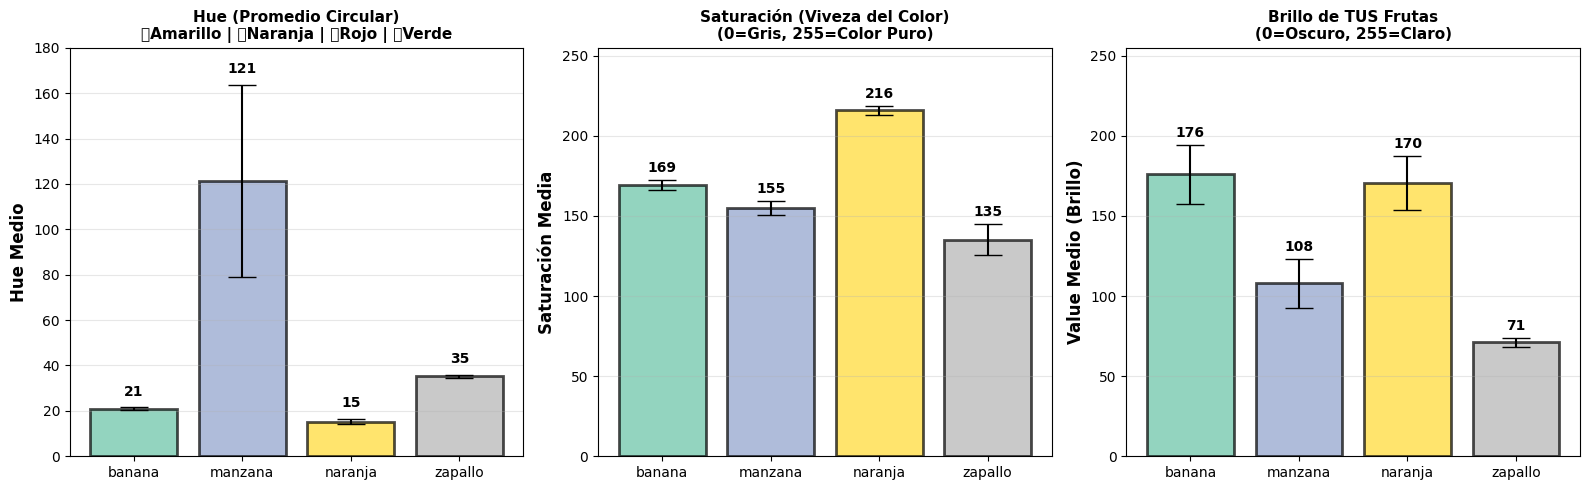


✓ Visualización completada

💡 NOTA: Si la Manzana Hue ~120 (verde), puede haber algunas manzanas verdes en tu dataset.


In [47]:
# Ejemplo: Visualizar valores MEDIOS de Hue y Saturación de cada fruta
print("="*70)
print("VALORES MEDIOS DE HUE Y SATURACIÓN POR FRUTA (SIN CONTAR EL FONDO NEGRO)")
print("="*70)

print("⚠️ Hue es CIRCULAR (Rojo=0-10 y 170-180). Usando coordenadas circulares (cos, sin) para promedio correcto.\n")

# Cargar todas las frutas
fruit_folders = {
    'banana': 'banana_sin_fondo',
    'manzana': 'manzana_sin_fondo',
    'naranja': 'naranja_sin_fondo',
    'zapallo': 'zapallo_sin_fondo'
}

all_stats = {}

for fruit_name, folder_name in fruit_folders.items():
    folder_path = os.path.join(data_path, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"⚠ {folder_name} no encontrada")
        continue
    
    images = sorted([f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    hue_values = []
    saturation_values = []
    value_values = []
    
    for img_name in images[:5]:  # Procesar primeras 5 imágenes
        try:
            img_path = os.path.join(folder_path, img_name)
            img_bgra = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            
            if img_bgra is None:
                continue
            
            # Redimensionar a 200x200
            img_resized = cv2.resize(img_bgra, (200, 200))
            
            # Separar RGB y ALPHA
            bgr = img_resized[:,:,:3]
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            alpha = img_resized[:,:,3] if img_resized.shape[2] == 4 else None
            
            # Convertir a HSV
            hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
            
            # ⭐ Usar máscara alpha para excluir el fondo negro
            if alpha is not None:
                # Crear máscara: solo píxeles con alpha > 127 (la fruta, no el fondo)
                mask = cv2.threshold(alpha, 127, 255, cv2.THRESH_BINARY)[1]
                
                # Calcular media SOLO en los píxeles de la fruta
                hue_mean = cv2.mean(hsv[:,:,0], mask=mask)[0]
                sat_mean = cv2.mean(hsv[:,:,1], mask=mask)[0]
                val_mean = cv2.mean(hsv[:,:,2], mask=mask)[0]
                
                # Contar píxeles válidos (para verificar)
                valid_pixels = np.count_nonzero(mask)
            else:
                # Si no hay alpha, usar la imagen completa (caso de respaldo)
                hue_mean = hsv[:,:,0].mean()
                sat_mean = hsv[:,:,1].mean()
                val_mean = hsv[:,:,2].mean()
                valid_pixels = hsv.shape[0] * hsv.shape[1]
            
            hue_values.append(hue_mean)
            saturation_values.append(sat_mean)
            value_values.append(val_mean)
            
        except Exception as e:
            pass
    
    if hue_values:
        # ⭐ Convertir Hue a coordenadas circulares (cos, sin) para promedio correcto
        hue_rad = np.radians(np.array(hue_values) * 2.0)  # 0-180 → 0-360 → radianes
        hue_circular_avg = np.degrees(np.arctan2(np.mean(np.sin(hue_rad)), np.mean(np.cos(hue_rad)))) / 2.0
        if hue_circular_avg < 0:
            hue_circular_avg += 180
        
        print(f"\n📊 {fruit_name.upper()}: Hue={hue_circular_avg:.1f}, Sat={np.mean(saturation_values):.1f}, Val={np.mean(value_values):.1f}")
        
        all_stats[fruit_name] = {
            'hue_mean': hue_circular_avg,
            'hue_std': np.std(hue_values),
            'sat_mean': np.mean(saturation_values),
            'sat_std': np.std(saturation_values),
            'val_mean': np.mean(value_values),
            'val_std': np.std(value_values)
        }

# Crear tabla comparativa
print("\n\n" + "="*70)
print("RESUMEN COMPARATIVO - TUS FRUTAS")
print("="*70)
print(f"{'Fruta':<15} {'Color Real':<15} {'Hue (0-180)':<18} {'Sat (0-255)':<15}")
print("-" * 70)

color_real_map = {
    'banana': 'Amarillo',
    'manzana': 'Rojo',
    'naranja': 'Naranja',
    'zapallo': 'Verde'
}

for fruit_name in fruit_folders.keys():
    if fruit_name in all_stats:
        stats = all_stats[fruit_name]
        color_real = color_real_map[fruit_name]
        hue_str = f"{stats['hue_mean']:.1f} ± {stats['hue_std']:.1f}"
        sat_str = f"{stats['sat_mean']:.1f} ± {stats['sat_std']:.1f}"
        print(f"{fruit_name.upper():<15} {color_real:<15} {hue_str:<18} {sat_str:<15}")

# Visualizar comparativa
if all_stats:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    fruits = list(all_stats.keys())
    hue_means = [all_stats[f]['hue_mean'] for f in fruits]
    hue_stds = [all_stats[f]['hue_std'] for f in fruits]
    sat_means = [all_stats[f]['sat_mean'] for f in fruits]
    sat_stds = [all_stats[f]['sat_std'] for f in fruits]
    val_means = [all_stats[f]['val_mean'] for f in fruits]
    val_stds = [all_stats[f]['val_std'] for f in fruits]
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(fruits)))
    
    # Gráfico de Hue (0-180)
    axes[0].bar(fruits, hue_means, yerr=hue_stds, capsize=10, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[0].set_ylabel('Hue Medio', fontsize=12, fontweight='bold')
    axes[0].set_title('Hue (Promedio Circular)\n🍌Amarillo | 🍊Naranja | 🍎Rojo | 🎃Verde', fontweight='bold', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim(0, 180)
    for i, (mean, std) in enumerate(zip(hue_means, hue_stds)):
        axes[0].text(i, mean + std + 5, f'{mean:.0f}', ha='center', fontweight='bold')
    
    # Gráfico de Saturación (0-255)
    axes[1].bar(fruits, sat_means, yerr=sat_stds, capsize=10, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[1].set_ylabel('Saturación Media', fontsize=12, fontweight='bold')
    axes[1].set_title('Saturación (Viveza del Color)\n(0=Gris, 255=Color Puro)', fontweight='bold', fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, 255)
    for i, (mean, std) in enumerate(zip(sat_means, sat_stds)):
        axes[1].text(i, mean + std + 5, f'{mean:.0f}', ha='center', fontweight='bold')
    
    # Gráfico de Value (brillo) (0-255)
    axes[2].bar(fruits, val_means, yerr=val_stds, capsize=10, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[2].set_ylabel('Value Medio (Brillo)', fontsize=12, fontweight='bold')
    axes[2].set_title('Brillo de TUS Frutas\n(0=Oscuro, 255=Claro)', fontweight='bold', fontsize=11)
    axes[2].grid(axis='y', alpha=0.3)
    axes[2].set_ylim(0, 255)
    for i, (mean, std) in enumerate(zip(val_means, val_stds)):
        axes[2].text(i, mean + std + 5, f'{mean:.0f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualización completada")
    print("\n💡 NOTA: Si la Manzana Hue ~120 (verde), puede haber algunas manzanas verdes en tu dataset.")

## Conclusión

✅ **Se extrajeron exitosamente los 516 features para cada fruta:**
- 2 Hu Moments (forma invariante a rotación/escala)
- 256 Histograma Hue (información de color)
- 256 Histograma Saturación (intensidad del color)
- 1 Circularidad (forma redonda vs alargada)
- 1 Compacidad (densidad de la forma)

**Suavizado aplicado:**
- Bilateral Filter: preserva bordes, suaviza interior
- Median Filter: elimina ruido
- Combinación: mejor resultado para contornos limpios

**Archivos generados:**
- `features_frutas.csv`: Todos los features de todas las frutas para usar en ML